# Test LC for injecting a variable before and after simulation

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

from platosim.plot import plotPhotometryFromHDF5, plotPSD
from platosim.noise import powerDensityFFT
from platosim.photometryfile import PhotometricFile
from platosim.quarterFile import timeQuarterFromOutputFile
from platosim.utilities import normalize

## Load simulations

In [2]:
filename0 = os.getcwd()+'/without_varsource_pic44942186_Ncam1.1_Q1.hdf5'
filename1 = os.getcwd()+'/with_varsource_pic44942186_Ncam1.1_Q1.hdf5'

file0 = h5py.File(filename0, 'r')
file1 = h5py.File(filename1, 'r')

data = np.loadtxt(os.getenv('PLATO_WORKDIR')+'/models/varsources/varsource_Sun_hotJupiter_2522882x25s.txt')
time = data[:,0]
df   = (10**(-data[:,1]/2.5) - 1) * 1e6

## Make plot of both simulations

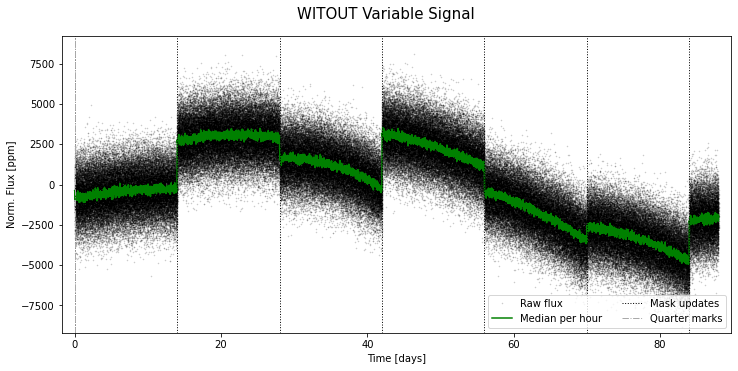

In [3]:
fig = plt.figure(figsize=(12,12))
ax = plotPhotometryFromHDF5(fig, filename0, title='WITOUT Variable Signal')
plt.show()

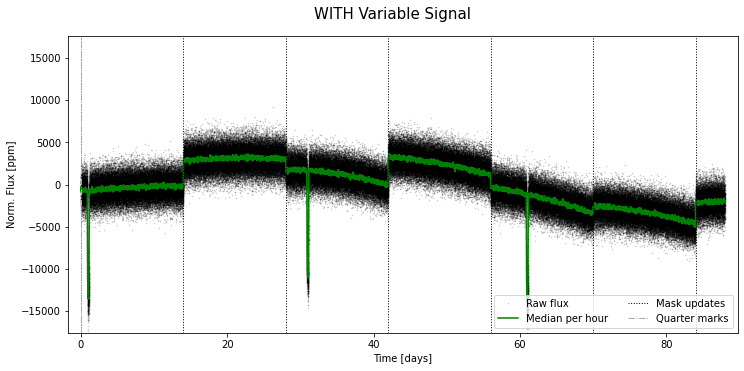

In [4]:
fig = plt.figure(figsize=(12,12))
plotPhotometryFromHDF5(fig, filename1, title='WITH Variable Signal')
plt.show()

## Inject variable signal to simulation without and compare

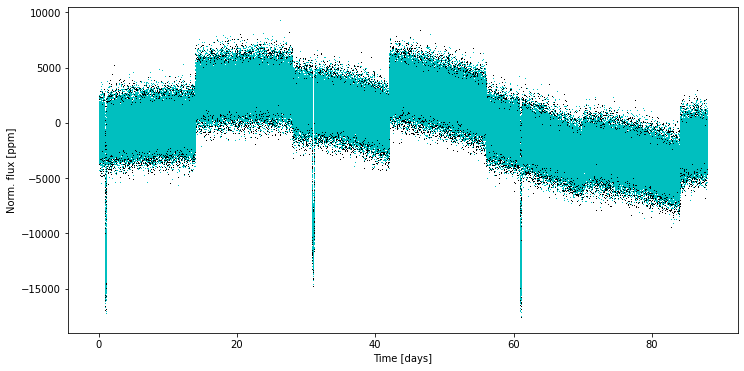

In [5]:
photclass0 = PhotometricFile(filename0)
photclass1 = PhotometricFile(filename1)

data0 = photclass0.getPhotometricTimeSeries(1)
flux0 = normalize(data0[2])

data1 = photclass1.getPhotometricTimeSeries(1)
flux1 = normalize(data1[2])

maskupdates = (data0[3] * 25.) / 86400  # [days] 

time = timeQuarterFromOutputFile(filename0, 1) / 86400.

flux2 = flux0+df[:len(flux0)]

plt.figure(figsize=(12,6))
plt.plot(time, flux2, 'k,')
plt.plot(time, flux1, 'c,')
plt.xlabel('Time [days]')
plt.ylabel('Norm. flux [ppm]')
plt.show()

## Find RMS of both signals after median filter has been subtracted

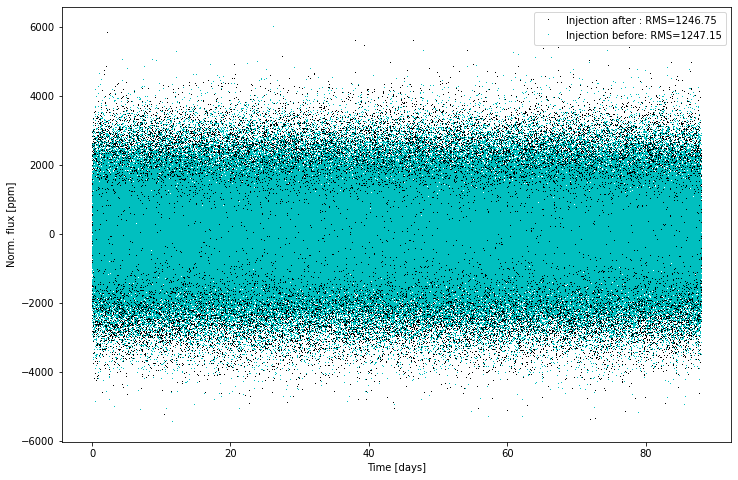

In [6]:
flux0_new = flux2 - median_filter(flux2, 144)  # 1 h = 144 time points
flux1_new = flux1 - median_filter(flux1, 144)

RMS_flux0 = np.sqrt(np.mean(flux0_new**2))
RMS_flux1 = np.sqrt(np.mean(flux1_new**2))

plt.figure(figsize=(12,8))
plt.plot(time, flux0_new, 'k,', label=f'Injection after : RMS={RMS_flux0:.2f}')
plt.plot(time, flux1_new, 'c,', label=f'Injection before: RMS={RMS_flux1:.2f}')
plt.legend()
plt.xlabel('Time [days]')
plt.ylabel('Norm. flux [ppm]')
plt.show()

## Check PSD

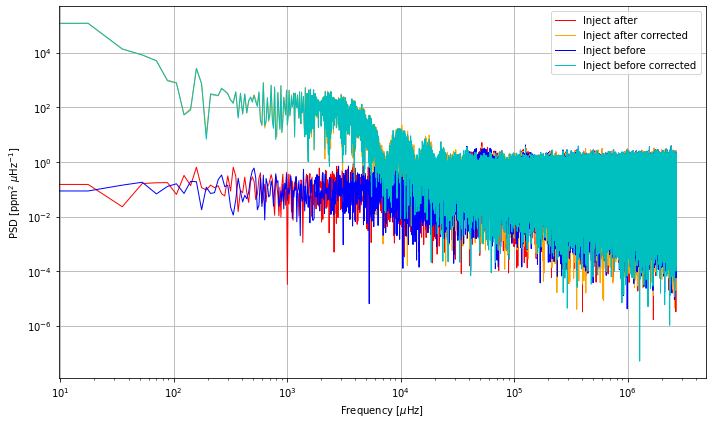

In [9]:
# Correct time to [Ms] and calculate PSD

time = time * 86400 * 1e-6
freq0, PSD0 = powerDensityFFT(flux2, np.diff(time)[0])
freq1, PSD1 = powerDensityFFT(flux1, np.diff(time)[0])
_, PSD0_white = powerDensityFFT(flux0_new, np.diff(time)[0])
_, PSD1_white = powerDensityFFT(flux1_new, np.diff(time)[0])

# Plot PSD

fig = plt.figure(figsize=(10,6))
plotPSD(fig, [freq0, freq0, freq1, freq1], [PSD0_white, PSD0, PSD1_white, PSD1], 
        carbox=False, linewidth=1, units=['$\mu$Hz', 'ppm'], colors=['r', 'orange', 'b', 'c'],
       labels=['Inject after', 'Inject after corrected', 'Inject before', 'Inject before corrected'])
plt.show()